In [8]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import librosa.display
from sklearn.utils.class_weight import compute_class_weight

# Configuration constants
SAMPLE_RATE = 22050  # Audio sample rate
CHUNK_DURATION = 13   # Duration of each audio chunk in seconds
HOP_DURATION = 1     # Step size for overlapping chunks in seconds
SAMPLES_PER_CHUNK = CHUNK_DURATION * SAMPLE_RATE # Number of samples in a chunk

In [9]:
pip install soundfile

In [10]:
def map_filename_to_label(filename):
    # Assigns a class label based on keywords in the filename.
    filename_lower = filename.lower()
    if "idle" in filename_lower:
        return "silence"
    elif "tap" in filename_lower:
        return "tap_water_running"
    elif "hand" in filename_lower:
        return "handwashing"
    elif "bottle" in filename_lower or "jug" in filename_lower:
        return "filling"
    elif "clean" in filename_lower or "utensil" in filename_lower:
        return "cleaning"
    else:
        return "unknown"

# Collect all .m4a files and assign labels, separating training and unseen test data
all_m4a_files = [f for f in os.listdir('.') if f.endswith('.m4a')]
train_classified_files = []
unseen_test_classified_files = []
label_to_example_file = {} # Store one example per class for EDA (from training files only)

print("Mapping audio files to activity labels and separating into training/test sets:")
for f in all_m4a_files:
    label = map_filename_to_label(f)
    if label != "unknown":
        if "test" in f.lower():
            unseen_test_classified_files.append((f, label))
            print(f"  '[TEST] {f}' -> {label}")
        else:
            train_classified_files.append((f, label))
            if label not in label_to_example_file:
                label_to_example_file[label] = f
            print(f"  '[TRAIN] {f}' -> {label}")
    else:
        print(f"  '[UNKNOWN] {f}' -> Unknown (Skipping for training/testing)")

if not train_classified_files and not unseen_test_classified_files:
    print("\nNo recognized .m4a audio files found in the current directory. Please upload them.")
else:
    print(f"\nFound {len(train_classified_files)} training audio segments.")
    print(f"Found {len(unseen_test_classified_files)} unseen test audio segments.")
    print(f"Training classes identified: {list(label_to_example_file.keys())}")


Mapping audio files to activity labels and separating into training/test sets:
  '[TRAIN] bottle_filling_sblock47.m4a' -> filling
  '[TRAIN] bottle_filling_pdgf789.m4a' -> filling
  '[TRAIN] bottle_sblockg4.m4a' -> filling
  '[TEST] utensils_cleaning_test_pd154.m4a' -> cleaning
  '[TRAIN] handwash_pd214.m4a' -> handwashing
  '[TRAIN] idle_env_224.m4a' -> silence
  '[TRAIN] bottle_filling_pdgf3.m4a' -> filling
  '[TRAIN] just_tap_sbkockg4.m4a' -> tap_water_running
  '[TRAIN] just_tap_sblock5.m4a' -> tap_water_running
  '[TRAIN] utensils_cleaning_pd_225.m4a' -> cleaning
  '[TRAIN] jug_filling_sblock54.m4a' -> filling
  '[TRAIN] bottle_filling_pdgf78.m4a' -> filling
  '[TRAIN] bottle_filling_pdgf5.m4a' -> filling
  '[TRAIN] hand_wash_pd19.m4a' -> handwashing
  '[TRAIN] utensil_cleaning_pd107_gan.m4a' -> cleaning
  '[TRAIN] handwash_sblock58.m4a' -> handwashing
  '[TRAIN] bottle_filling_pdwr62.m4a' -> filling
  '[TRAIN] bottle_filling_pd_gf5.m4a' -> filling
  '[TRAIN] hand_washing_sblockg1

In [11]:
def extract_features_for_chunk(chunk, sr=SAMPLE_RATE, apply_frequency_masking=False):
    # Skip very short chunks
    if len(chunk) < sr * 0.01:
        return None

    # Normalize audio volume before extracting features
    chunk = librosa.util.normalize(chunk)

    # 1. Extract base MFCCs and Deltas (Pitch and Rhythm)
    mfccs = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=13)

    if apply_frequency_masking:
        num_rows_to_mask = np.random.randint(1, 3)
        rows_to_mask = np.random.choice(mfccs.shape[0], num_rows_to_mask, replace=False)
        mfccs[rows_to_mask, :] = 0

    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)

    # 2. NEW: Extract Texture Features (Harshness, Brightness, Peaks)
    zcr = librosa.feature.zero_crossing_rate(chunk)
    centroid = librosa.feature.spectral_centroid(y=chunk, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=chunk, sr=sr)

    # 3. Calculate Mean, Std, Max for all features
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std = np.std(mfccs.T, axis=0)
    mfccs_max = np.max(mfccs.T, axis=0)

    delta_mean = np.mean(delta_mfccs.T, axis=0)
    delta_std = np.std(delta_mfccs.T, axis=0)
    delta_max = np.max(delta_mfccs.T, axis=0)

    delta2_mean = np.mean(delta2_mfccs.T, axis=0)
    delta2_std = np.std(delta2_mfccs.T, axis=0)
    delta2_max = np.max(delta2_mfccs.T, axis=0)

    # NEW: Average out the new texture features
    zcr_mean = np.mean(zcr.T, axis=0)
    centroid_mean = np.mean(centroid.T, axis=0)
    contrast_mean = np.mean(contrast.T, axis=0)

    # 4. Stack EVERYTHING into one massive array
    features = np.hstack([
        mfccs_mean, mfccs_std, mfccs_max,
        delta_mean, delta_std, delta_max,
        delta2_mean, delta2_std, delta2_max,
        zcr_mean, centroid_mean, contrast_mean # The new separators
    ])

    return features

In [12]:
# 4. Data Augmentation Helper Functions

def add_random_noise(signal, noise_factor=0.005):
    # Adds random white noise to an audio signal.
    noise = np.random.randn(len(signal)) # Generate Gaussian noise
    augmented_signal = signal + noise_factor * noise
    return augmented_signal

def add_random_amplitude_scaling(signal, scale_range=(0.5, 1.5)):
    # Scales the amplitude of an audio signal by a random factor.
    scale_factor = np.random.uniform(scale_range[0], scale_range[1])
    augmented_signal = signal * scale_factor
    return augmented_signal

In [13]:
# 5. Feature Extraction: Mean, Standard Deviation, Max, and Deltas

def extract_features_for_chunk(chunk, sr=SAMPLE_RATE, apply_frequency_masking=False):
    # Skip very short chunks
    if len(chunk) < sr * 0.01:
        return None

    # NEW: Normalize audio volume before extracting features
    chunk = librosa.util.normalize(chunk)

    # Extract base MFCCs
    mfccs = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=13)

    # Apply frequency masking if augment is True
    if apply_frequency_masking:
        num_rows_to_mask = np.random.randint(1, 3)
        rows_to_mask = np.random.choice(mfccs.shape[0], num_rows_to_mask, replace=False)
        mfccs[rows_to_mask, :] = 0

    # NEW: Extract Delta and Delta-Delta MFCCs (captures rhythm)
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)

    # Calculate mean, std, max for base MFCCs
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std = np.std(mfccs.T, axis=0)
    mfccs_max = np.max(mfccs.T, axis=0)

    # Calculate mean, std, max for Delta MFCCs
    delta_mean = np.mean(delta_mfccs.T, axis=0)
    delta_std = np.std(delta_mfccs.T, axis=0)
    delta_max = np.max(delta_mfccs.T, axis=0)

    # Calculate mean, std, max for Delta-Delta MFCCs
    delta2_mean = np.mean(delta2_mfccs.T, axis=0)
    delta2_std = np.std(delta2_mfccs.T, axis=0)
    delta2_max = np.max(delta2_mfccs.T, axis=0)

    # Stack all 117 features together into a single 1D array
    features = np.hstack([
        mfccs_mean, mfccs_std, mfccs_max,
        delta_mean, delta_std, delta_max,
        delta2_mean, delta2_std, delta2_max
    ])

    return features

In [14]:
def process_audio_file(file_path, label_str, augment=False):
    features = []
    labels = []

    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # Calculate number of samples for hop and chunk
    hop_samples = int(HOP_DURATION * sr)
    chunk_samples = int(CHUNK_DURATION * sr)

    # Chunk the audio with overlap
    for i in range(0, len(y) - chunk_samples + 1, hop_samples):
        chunk = y[i : i + chunk_samples]

        # Apply augmentation if requested
        if augment:
            # Apply frequency masking during feature extraction for augmented data
            # Apply random noise and amplitude scaling with 50% probability each
            if np.random.rand() > 0.5:
                chunk = add_random_noise(chunk)
            if np.random.rand() > 0.5:
                chunk = add_random_amplitude_scaling(chunk)

        # Extract features for the chunk. Apply frequency masking only for augmented data
        chunk_features = extract_features_for_chunk(chunk, sr=sr, apply_frequency_masking=augment)
        if chunk_features is not None:
            features.append(chunk_features)
            labels.append(label_str)

    return features, labels


--- Starting Data Processing and Model Training ---

--- Processing Training Data ---
Extracting features and applying augmentation for training files...


/tmp/ipykernel_779/2346297460.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_779/2346297460.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_779/2346297460.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/d

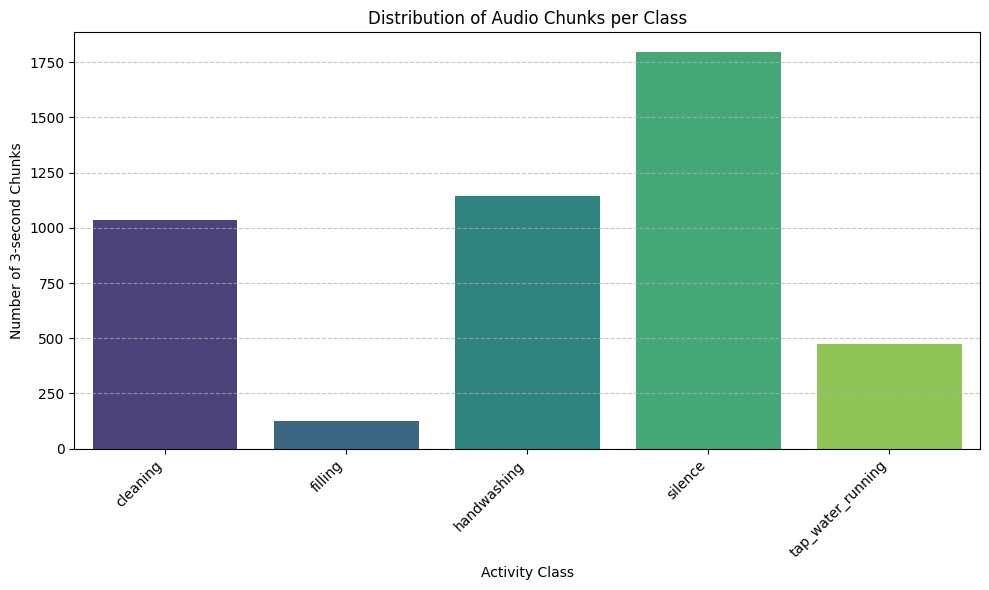

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 6. Data Loading, Feature Extraction, and Model Development
print("\n--- Starting Data Processing and Model Training ---")

# --- Part 1: Process Training Data ---
print("\n--- Processing Training Data ---")
X_train_raw = []
y_train_raw = []

print("Extracting features and applying augmentation for training files...")
for file_path, label_str in train_classified_files:
    # Process original chunks
    features_orig, labels_orig = process_audio_file(file_path, label_str, augment=False)
    X_train_raw.extend(features_orig)
    y_train_raw.extend(labels_orig)

    # Process augmented chunks
    features_aug, labels_aug = process_audio_file(file_path, label_str, augment=True)
    X_train_raw.extend(features_aug)
    y_train_raw.extend(labels_aug)

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)
# Get the counts for each class
class_counts = pd.Series(y_train_raw).value_counts().sort_index()

# Create a DataFrame for plotting
class_distribution_df = pd.DataFrame({
    'Class': class_counts.index,
    'Number of Chunks': class_counts.values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Number of Chunks', data=class_distribution_df, palette='viridis')
plt.title('Distribution of Audio Chunks per Class')
plt.xlabel('Activity Class')
plt.ylabel('Number of 3-second Chunks')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA) of Features

Now that we have extracted features from our audio chunks, let's perform some Exploratory Data Analysis to understand their distribution and relationships. Given the high dimensionality of our feature set (117 features), we'll use Principal Component Analysis (PCA) to reduce the dimensions and visualize the data in 2D, colored by activity class. This will help us understand if the different activity types are distinct based on the extracted features.

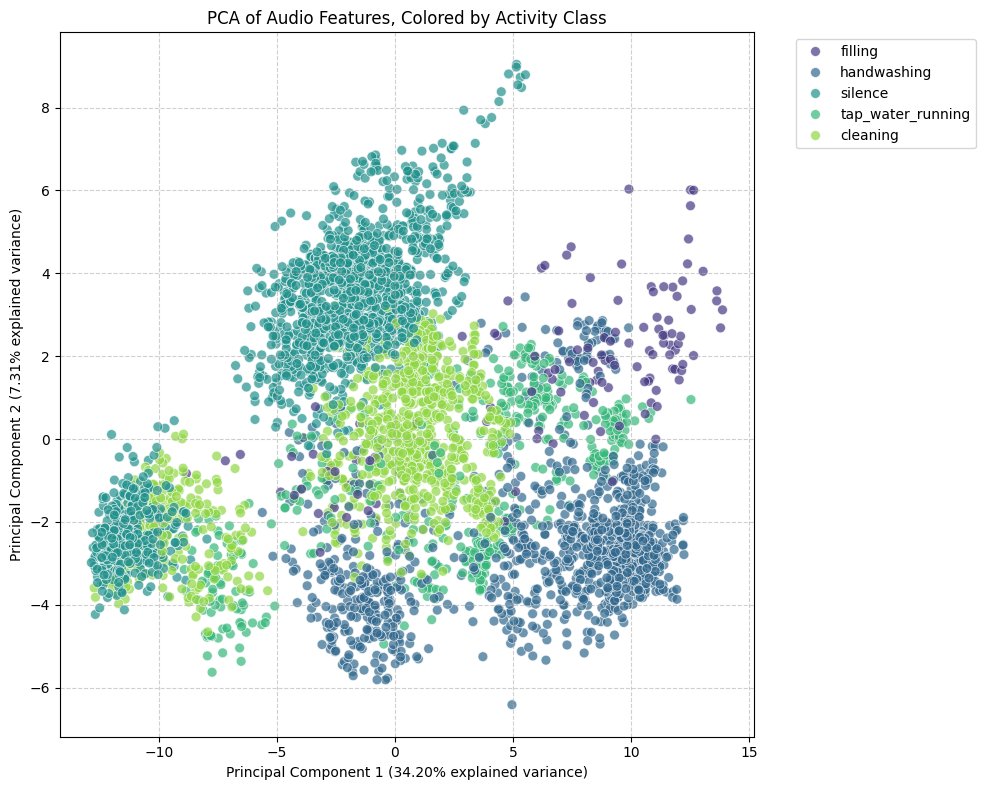

In [16]:
from sklearn.decomposition import PCA

# Re-encode labels for EDA if label_encoder from 5bd8a96a is not directly in scope
# (Though it typically would be after that cell runs, re-initializing here ensures independence for this visualization)
label_encoder_eda = LabelEncoder()
y_encoded_eda = label_encoder_eda.fit_transform(y_train_raw)
class_names_eda = label_encoder_eda.classes_

# Scale features for PCA. Use a new scaler here to avoid interference with the model's scaler.
scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(X_train_raw)

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled_eda)

# Create a DataFrame for easy plotting with seaborn
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Activity'] = [class_names_eda[label] for label in y_encoded_eda] # Map back to original class names

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Activity',
    data=pca_df,
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('PCA of Audio Features, Colored by Activity Class')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% explained variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% explained variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

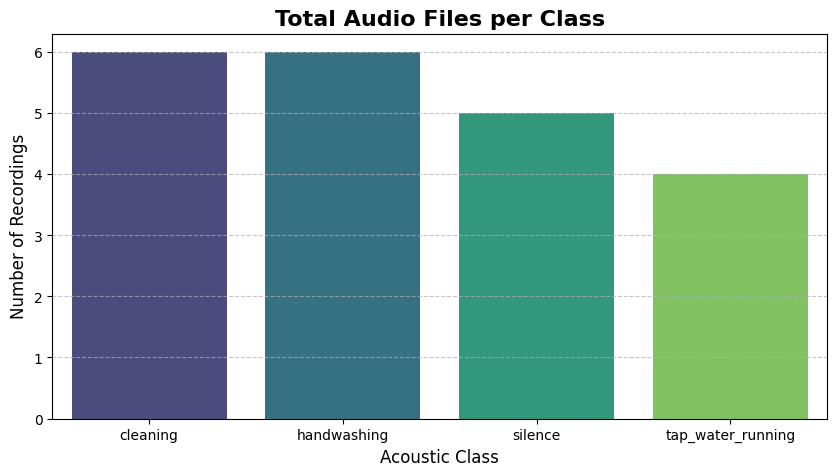

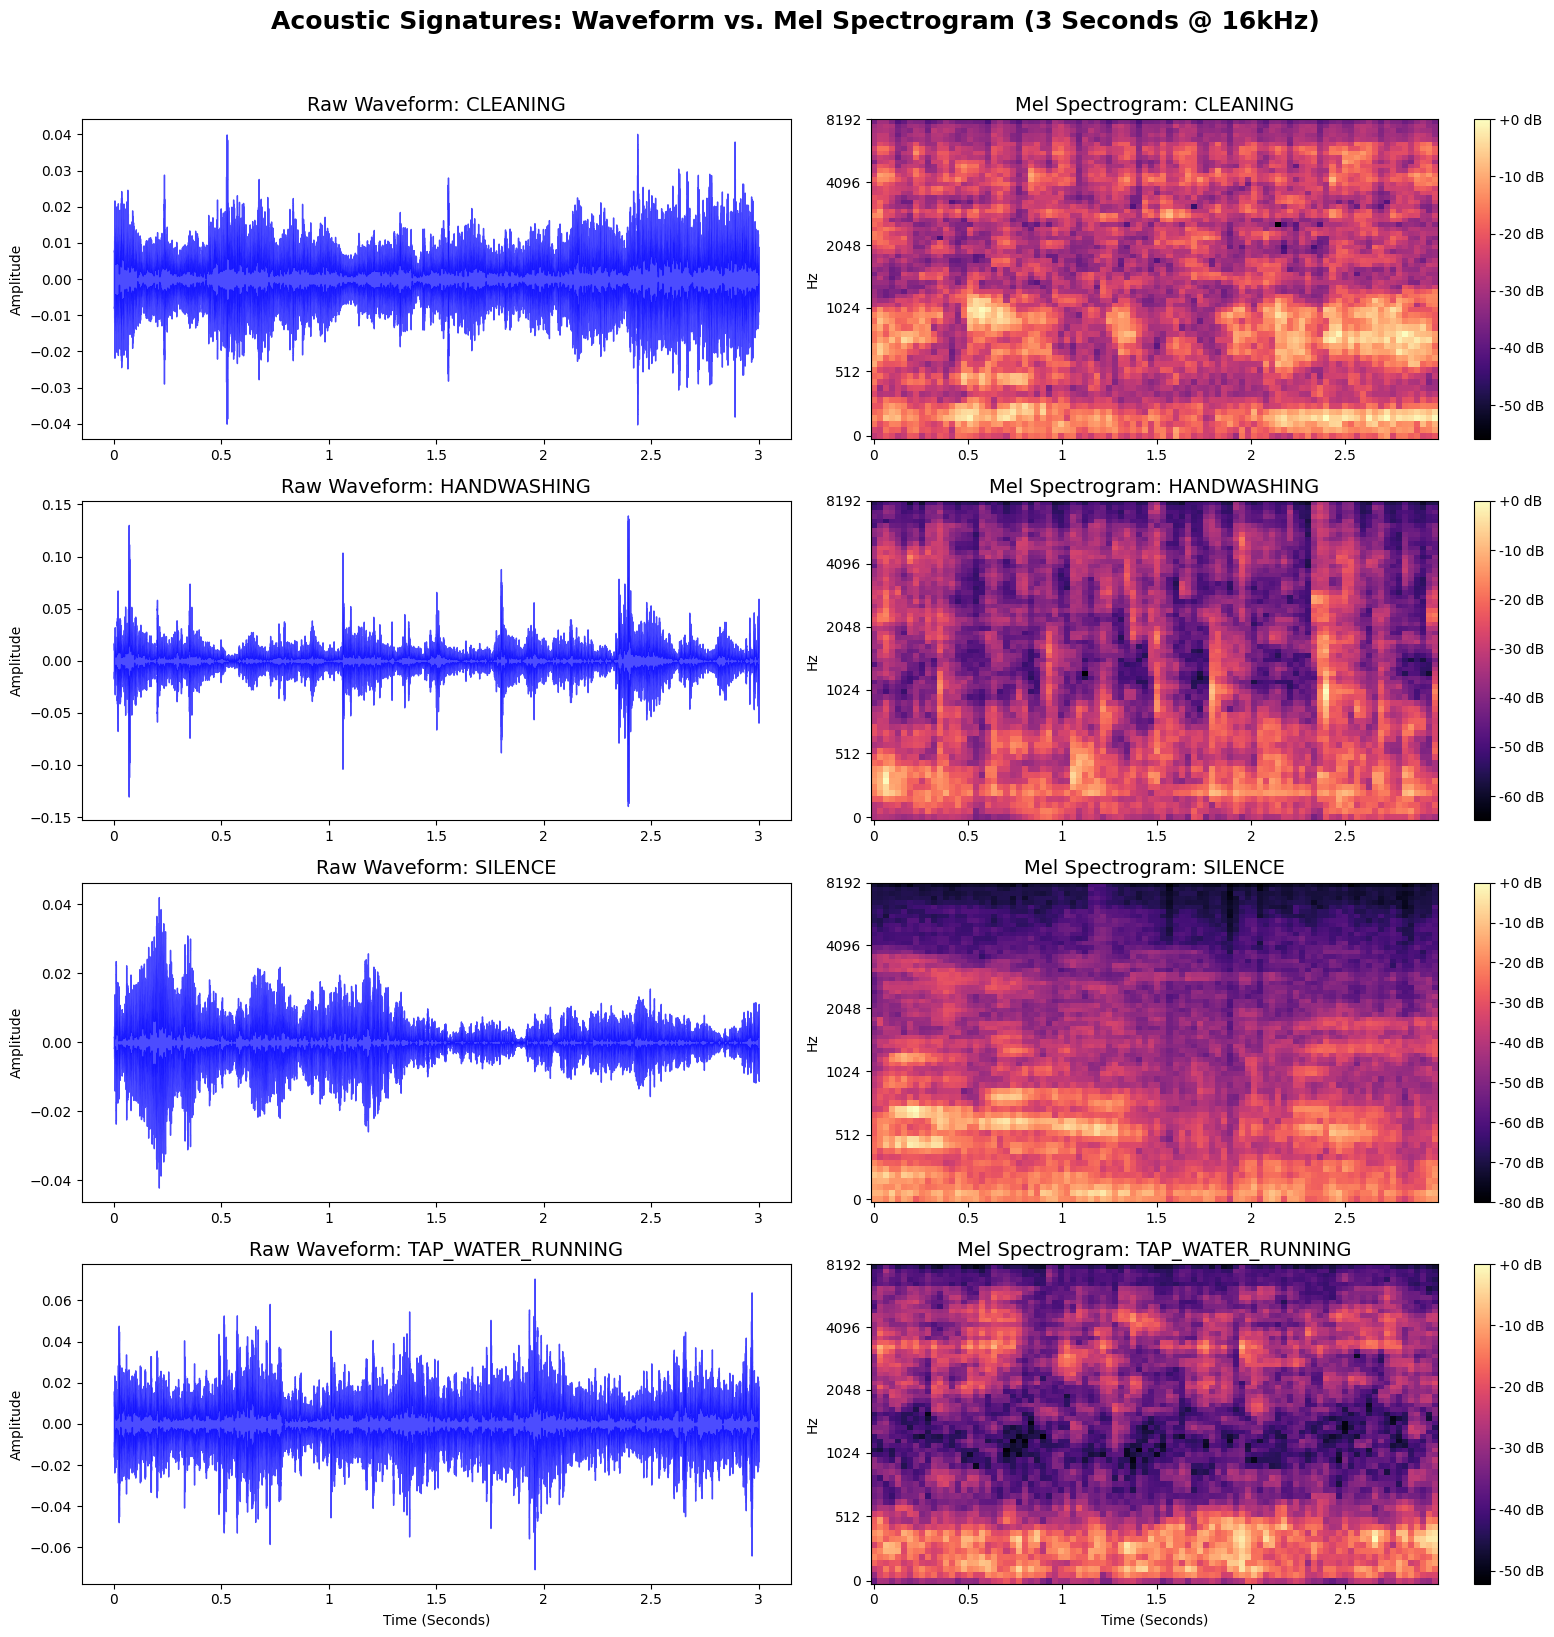

In [17]:
import os
import random
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mute warnings for a clean output
import warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
SAMPLE_RATE = 16000
CHUNK_DURATION = 3
CHUNK_SAMPLES = SAMPLE_RATE * CHUNK_DURATION
DATA_DIR = '.' # Change this if your data is in a subfolder like '/content/data'

# --- 2. EXTRACT LABELS AND COUNT DATA ---
def extract_label(filename):
    fname = filename.lower()
    if 'idle' in fname: return 'silence'
    if 'tap' in fname: return 'tap_water_running'
    if 'hand' in fname: return 'handwashing'
    if 'clean' in fname or 'utensil' in fname: return 'cleaning'
    return 'unknown'

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(('.wav', '.flac', '.m4a'))]
file_label_pairs = [(os.path.join(DATA_DIR, f), extract_label(f)) for f in all_files]
file_label_pairs = [x for x in file_label_pairs if x[1] != 'unknown']

# Count how many files per class
class_counts = {}
sample_files = {} # We will save one file from each class to visualize

for filepath, label in file_label_pairs:
    class_counts[label] = class_counts.get(label, 0) + 1
    if label not in sample_files:
        sample_files[label] = filepath # Grab the first file found for this class

# --- VISUALIZATION 1: CLASS DISTRIBUTION (BAR CHART) ---
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Total Audio Files per Class", fontsize=16, fontweight='bold')
plt.xlabel("Acoustic Class", fontsize=12)
plt.ylabel("Number of Recordings", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- VISUALIZATION 2 & 3: WAVEFORMS AND MEL SPECTROGRAMS ---
# We will create a grid: Left column = Raw Waveform, Right Column = Spectrogram
num_classes = len(sample_files)
fig, axes = plt.subplots(nrows=num_classes, ncols=2, figsize=(16, 4 * num_classes))
fig.suptitle("Acoustic Signatures: Waveform vs. Mel Spectrogram (3 Seconds @ 16kHz)", fontsize=18, fontweight='bold', y=1.02)

for i, (label, filepath) in enumerate(sample_files.items()):
    # Load and trim 3 seconds of audio
    audio, sr = librosa.load(filepath, sr=SAMPLE_RATE)

    # If the audio is longer than 3 seconds, just take a 3-second slice from the middle to get good action
    if len(audio) > CHUNK_SAMPLES:
        start_idx = (len(audio) // 2) - (CHUNK_SAMPLES // 2)
        audio = audio[start_idx : start_idx + CHUNK_SAMPLES]
    elif len(audio) < CHUNK_SAMPLES:
        audio = np.pad(audio, (0, CHUNK_SAMPLES - len(audio)))

    # --- PLOT RAW WAVEFORM (LEFT) ---
    ax_wave = axes[i, 0]
    librosa.display.waveshow(audio, sr=SAMPLE_RATE, ax=ax_wave, color='blue', alpha=0.7)
    ax_wave.set_title(f"Raw Waveform: {label.upper()}", fontsize=14)
    ax_wave.set_ylabel("Amplitude")
    if i == num_classes - 1:
        ax_wave.set_xlabel("Time (Seconds)")
    else:
        ax_wave.set_xlabel("")

    # --- PLOT MEL SPECTROGRAM (RIGHT) ---
    ax_spec = axes[i, 1]
    # Calculate the spectrogram exactly how the TensorFlow model will do it
    mel = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_fft=1024, hop_length=512, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(mel_db, sr=SAMPLE_RATE, hop_length=512, x_axis='time', y_axis='mel', ax=ax_spec, cmap='magma')
    ax_spec.set_title(f"Mel Spectrogram: {label.upper()}", fontsize=14)
    fig.colorbar(img, ax=ax_spec, format="%+2.0f dB")
    if i == num_classes - 1:
        ax_spec.set_xlabel("Time (Seconds)")
    else:
        ax_spec.set_xlabel("")

plt.tight_layout()
plt.show()

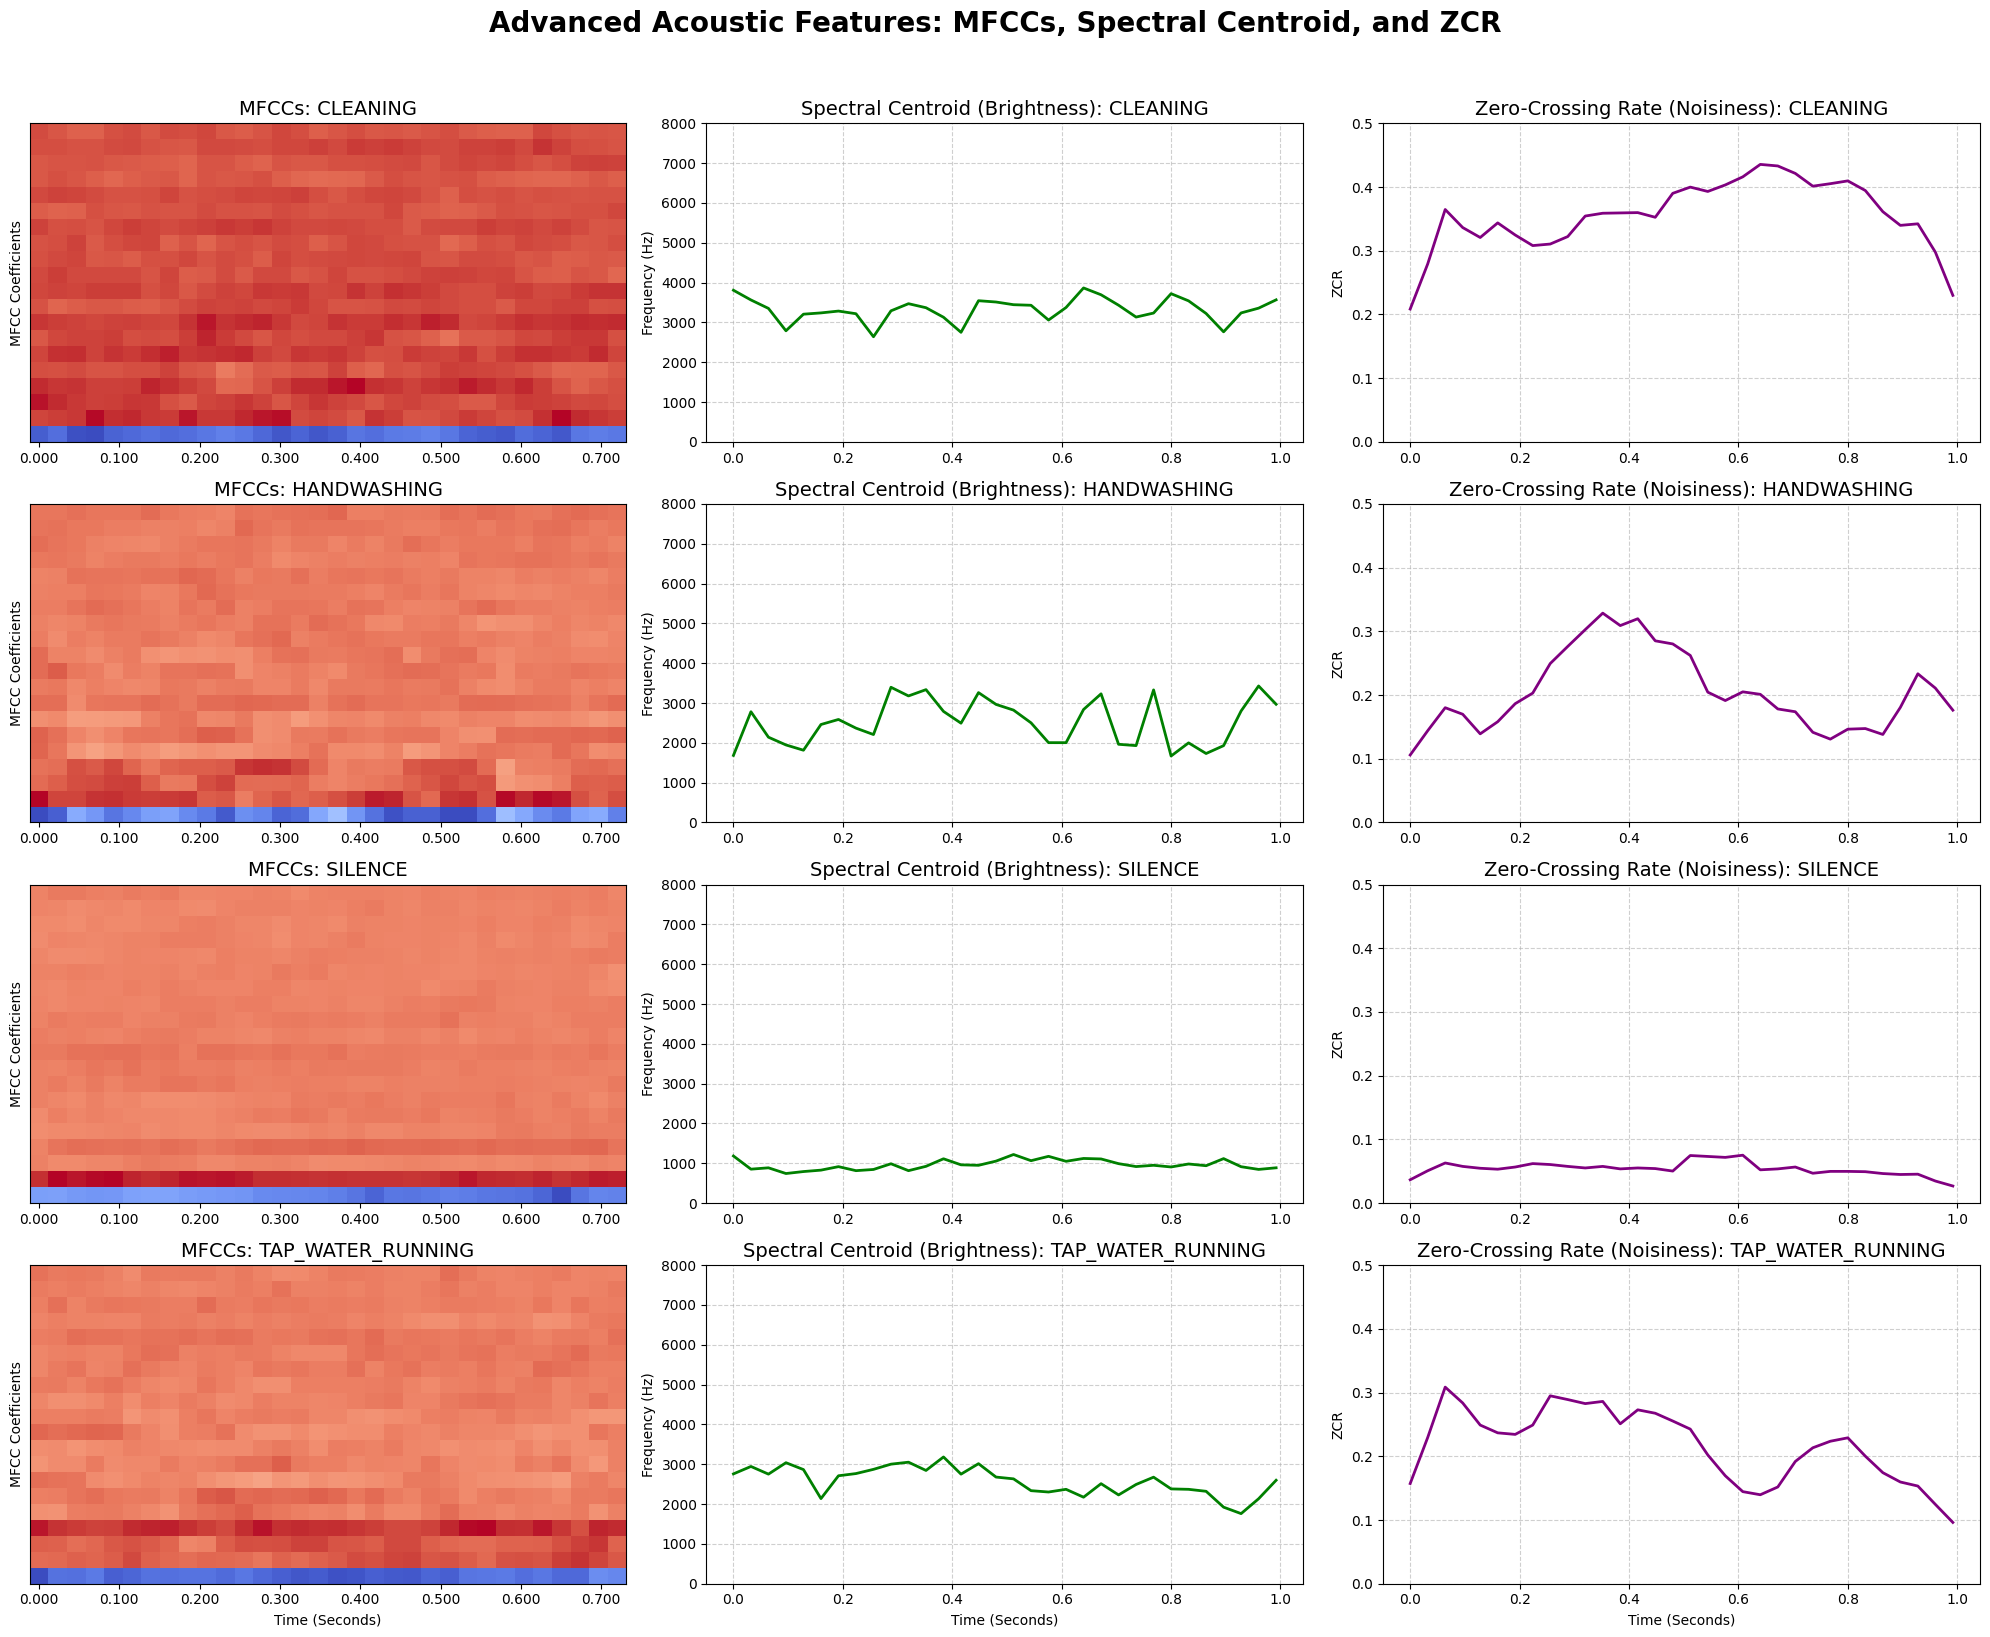

In [21]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
SAMPLE_RATE = 16000
CHUNK_DURATION = 1
CHUNK_SAMPLES = SAMPLE_RATE * CHUNK_DURATION
DATA_DIR = '.'

# --- 2. EXTRACT LABELS AND SAMPLE DATA ---
def extract_label(filename):
    fname = filename.lower()
    if 'idle' in fname: return 'silence'
    if 'tap' in fname: return 'tap_water_running'
    if 'hand' in fname: return 'handwashing'
    if 'clean' in fname or 'utensil' in fname: return 'cleaning'
    return 'unknown'

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(('.wav', '.flac', '.m4a'))]
file_label_pairs = [(os.path.join(DATA_DIR, f), extract_label(f)) for f in all_files]
sample_files = {}

for filepath, label in file_label_pairs:
    if label != 'unknown' and label not in sample_files:
        sample_files[label] = filepath

# --- 3. VISUALIZE MFCCs, CENTROID, AND ZCR ---
num_classes = len(sample_files)
fig, axes = plt.subplots(nrows=num_classes, ncols=3, figsize=(20, 4 * num_classes))
fig.suptitle("Advanced Acoustic Features: MFCCs, Spectral Centroid, and ZCR", fontsize=20, fontweight='bold', y=1.02)

for i, (label, filepath) in enumerate(sample_files.items()):
    # Load and trim exactly like the CNN pipeline
    audio, sr = librosa.load(filepath, sr=SAMPLE_RATE)
    if len(audio) > CHUNK_SAMPLES:
        start_idx = (len(audio) // 2) - (CHUNK_SAMPLES // 2)
        audio = audio[start_idx : start_idx + CHUNK_SAMPLES]
    elif len(audio) < CHUNK_SAMPLES:
        audio = np.pad(audio, (0, CHUNK_SAMPLES - len(audio)))

    # Calculate Features mathematically
    # 1. MFCCs (Compressed feature representation using DCT)
    mfccs = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=20, n_fft=1024, hop_length=512)

    # 2. Spectral Centroid (Center of mass of the frequency spectrum)
    centroid = librosa.feature.spectral_centroid(y=audio, sr=SAMPLE_RATE, n_fft=1024, hop_length=512)[0]

    # 3. Zero-Crossing Rate (Rate of sign-changes along the signal)
    zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=512)[0]

    # Time array for plotting 1D features
    times = librosa.times_like(centroid, sr=SAMPLE_RATE, hop_length=512)

    # --- PLOT 1: MFCCs (Left) ---
    ax_mfcc = axes[i, 0]
    img = librosa.display.specshow(mfccs, x_axis='time', ax=ax_mfcc, cmap='coolwarm')
    ax_mfcc.set_title(f"MFCCs: {label.upper()}", fontsize=14)
    ax_mfcc.set_ylabel("MFCC Coefficients")
    if i == num_classes - 1: ax_mfcc.set_xlabel("Time (Seconds)")
    else: ax_mfcc.set_xlabel("")

    # --- PLOT 2: Spectral Centroid (Middle) ---
    ax_cent = axes[i, 1]
    ax_cent.plot(times, centroid, color='green', linewidth=2)
    ax_cent.set_title(f"Spectral Centroid (Brightness): {label.upper()}", fontsize=14)
    ax_cent.set_ylabel("Frequency (Hz)")
    ax_cent.grid(True, linestyle='--', alpha=0.6)
    # Standardize y-axis so it's easy to compare across classes
    ax_cent.set_ylim(0, 8000)
    if i == num_classes - 1: ax_cent.set_xlabel("Time (Seconds)")

    # --- PLOT 3: Zero-Crossing Rate (Right) ---
    ax_zcr = axes[i, 2]
    ax_zcr.plot(times, zcr, color='purple', linewidth=2)
    ax_zcr.set_title(f"Zero-Crossing Rate (Noisiness): {label.upper()}", fontsize=14)
    ax_zcr.set_ylabel("ZCR")
    ax_zcr.grid(True, linestyle='--', alpha=0.6)
    ax_zcr.set_ylim(0, 0.5)
    if i == num_classes - 1: ax_zcr.set_xlabel("Time (Seconds)")

plt.tight_layout()
plt.show()

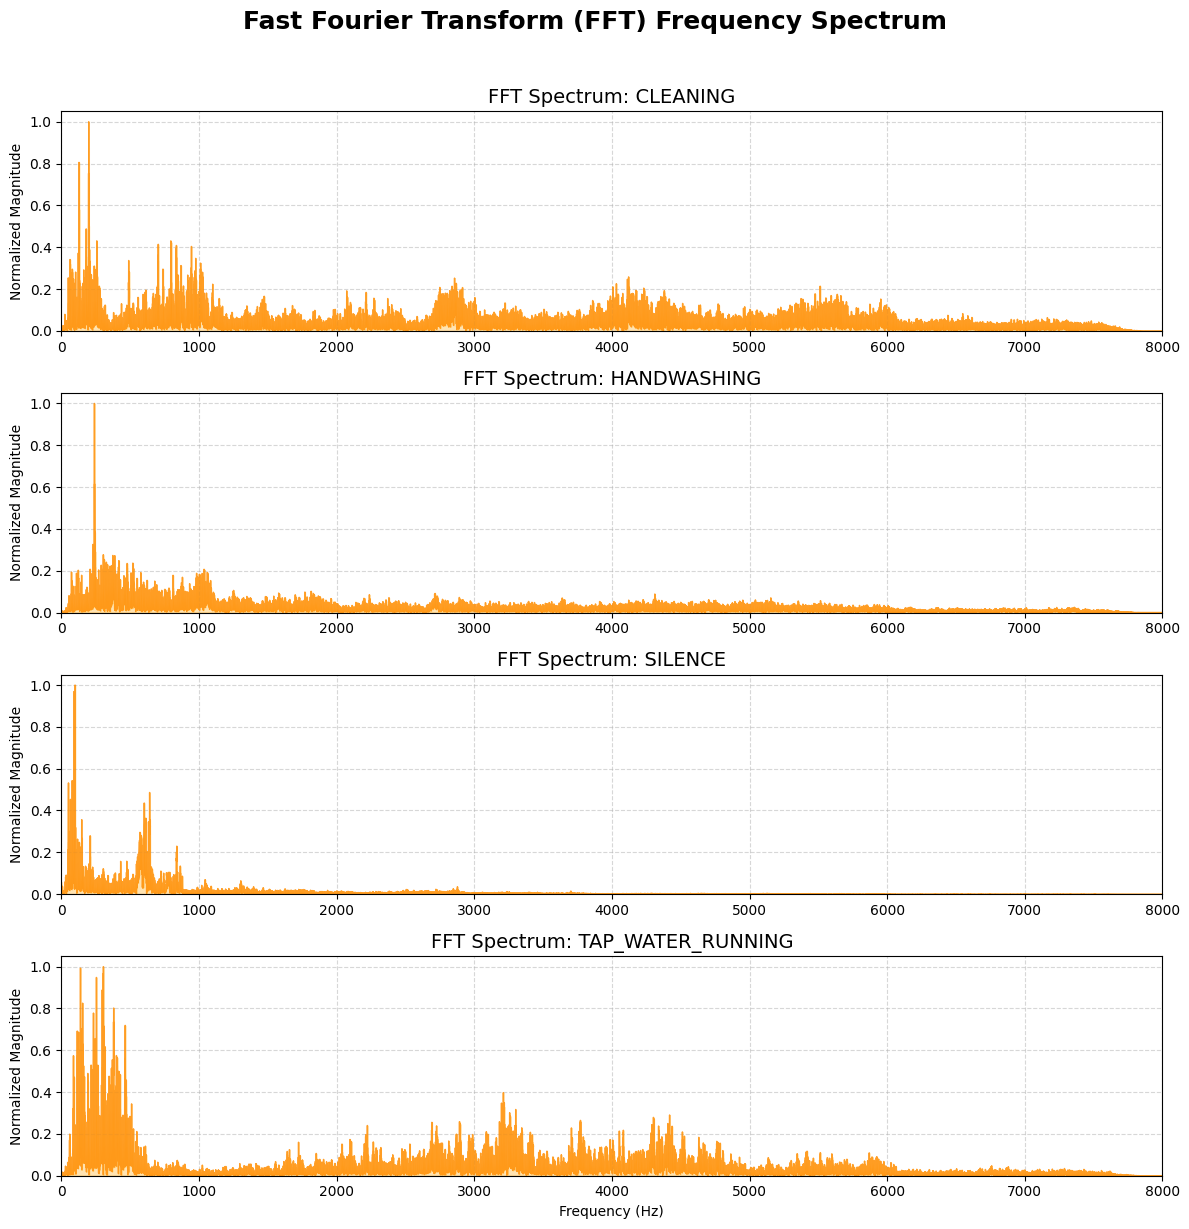

In [20]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
SAMPLE_RATE = 16000
CHUNK_DURATION = 3
CHUNK_SAMPLES = SAMPLE_RATE * CHUNK_DURATION
DATA_DIR = '.'

# --- 2. EXTRACT LABELS AND SAMPLE DATA ---
def extract_label(filename):
    fname = filename.lower()
    if 'idle' in fname: return 'silence'
    if 'tap' in fname: return 'tap_water_running'
    if 'hand' in fname: return 'handwashing'
    if 'clean' in fname or 'utensil' in fname: return 'cleaning'
    return 'unknown'

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(('.wav', '.flac', '.m4a'))]
file_label_pairs = [(os.path.join(DATA_DIR, f), extract_label(f)) for f in all_files]
sample_files = {}

for filepath, label in file_label_pairs:
    if label != 'unknown' and label not in sample_files:
        sample_files[label] = filepath

# --- 3. CALCULATE AND VISUALIZE FFT ---
num_classes = len(sample_files)
fig, axes = plt.subplots(nrows=num_classes, ncols=1, figsize=(12, 3 * num_classes))
fig.suptitle("Fast Fourier Transform (FFT) Frequency Spectrum", fontsize=18, fontweight='bold', y=1.02)

# If there's only one class, axes might not be an array, so we ensure it is
if num_classes == 1: axes = [axes]

for i, (label, filepath) in enumerate(sample_files.items()):
    # Load and trim
    audio, sr = librosa.load(filepath, sr=SAMPLE_RATE)
    if len(audio) > CHUNK_SAMPLES:
        start_idx = (len(audio) // 2) - (CHUNK_SAMPLES // 2)
        audio = audio[start_idx : start_idx + CHUNK_SAMPLES]
    elif len(audio) < CHUNK_SAMPLES:
        audio = np.pad(audio, (0, CHUNK_SAMPLES - len(audio)))

    # --- FFT MATHEMATICS ---
    # Apply a window function (Hanning) to prevent spectral leakage at the edges
    windowed_audio = audio * np.hanning(len(audio))

    # Calculate the Real FFT (since audio is real numbers, not complex)
    fft_values = np.fft.rfft(windowed_audio)

    # Get the Magnitude (Absolute value of the complex numbers)
    fft_magnitude = np.abs(fft_values)

    # Get the exact Frequency bins (X-axis) for the 16kHz sample rate
    frequencies = np.fft.rfftfreq(len(windowed_audio), d=1/SAMPLE_RATE)

    # Normalize the magnitude so it's easier to visually compare
    fft_magnitude_norm = fft_magnitude / np.max(fft_magnitude) if np.max(fft_magnitude) > 0 else fft_magnitude

    # --- PLOT ---
    ax = axes[i]
    # We only plot up to 8000 Hz (the Nyquist limit for 16kHz audio)
    ax.plot(frequencies, fft_magnitude_norm, color='darkorange', alpha=0.8, linewidth=1)
    ax.fill_between(frequencies, fft_magnitude_norm, color='orange', alpha=0.3)

    ax.set_title(f"FFT Spectrum: {label.upper()}", fontsize=14)
    ax.set_ylabel("Normalized Magnitude")
    ax.set_xlim(0, 8000) # Lock X-axis to standard 0-8kHz range
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)

    if i == num_classes - 1:
        ax.set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.show()